# Gating / promotion outcomes per ablation

Per-iteration gating outcome plus rolling promotion rate.

In [ ]:
import json
import matplotlib.pyplot as plt

def plot_promotion(log_path: str, title: str, window: int = 20):
    with open(log_path) as f:
        log = json.load(f)
    iters           = [e['iteration'] for e in log if 'gating' in e]
    promoted_iters  = [e['iteration'] for e in log if e.get('gating', {}).get('promoted')]
    retained_iters  = [e['iteration'] for e in log if 'gating' in e and not e['gating'].get('promoted')]
    if not iters:
        print(f'{log_path}: no gating entries')
        return
    print(f'{log_path}: iters={len(iters)} promoted={len(promoted_iters)} retained={len(retained_iters)} '
          f'overall_rate={len(promoted_iters)/len(iters):.1%}')

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [1, 2]})
    ax1, ax2 = axes
    ax1.scatter(promoted_iters, [1] * len(promoted_iters), c='green', s=20, label=f'Promoted ({len(promoted_iters)})')
    ax1.scatter(retained_iters, [2] * len(retained_iters), c='red',   s=20, label=f'Retained ({len(retained_iters)})')
    ax1.set_yticks([1, 2], ['promoted', 'retained'])
    ax1.set_ylim(0.5, 2.5)
    ax1.set_title(f'Gating outcome per iteration — {title}')
    ax1.grid(True, axis='x', alpha=0.3)
    ax1.legend(loc='center right')

    flags = [1 if e.get('gating', {}).get('promoted') else 0 for e in log if 'gating' in e]
    rolling = [sum(flags[max(0, i - window + 1) : i + 1]) / min(window, i + 1) for i in range(len(flags))]
    ax2.plot(iters, rolling, linewidth=1.8, color='C2')
    ax2.axhline(0.5, color='grey', linestyle=':', alpha=0.6, label='50%')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel(f'Promotion rate ({window}-iter rolling)')
    ax2.set_title(f'Challenger promotion rate — {title}')
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()


## Ablation 1 — Baseline (buffer 30k, gate 20, steps 150)

results/abl1_baseline/training_log.json: iters=337 promoted=91 retained=246 overall_rate=27.0%


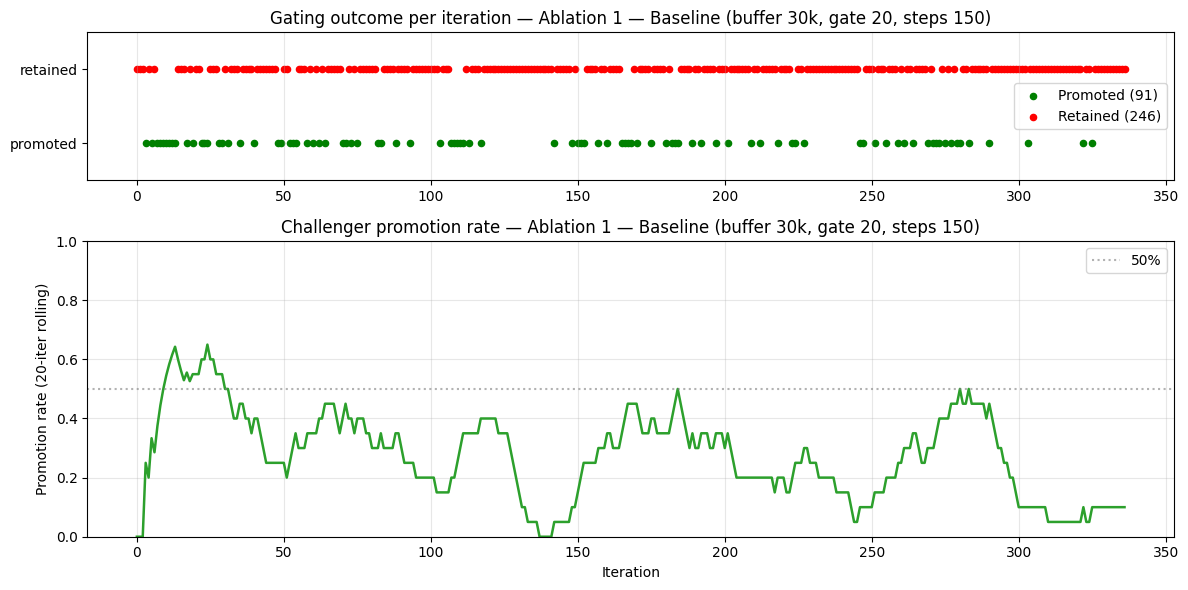

In [ ]:
plot_promotion('results/abl1_baseline/training_log.json', 'Ablation 1 — Baseline (buffer 30k, gate 20, steps 150)')

## Ablation 2 — Buffer 10k

results/abl2_buffer_10k/training_log.json: iters=302 promoted=78 retained=224 overall_rate=25.8%


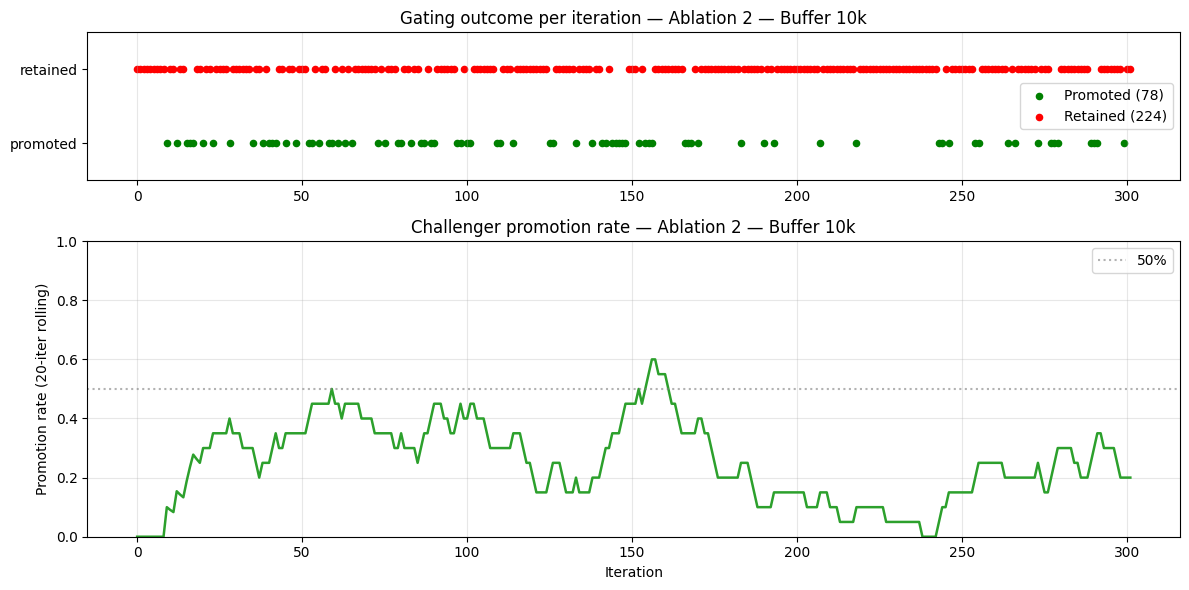

In [ ]:
plot_promotion('results/abl2_buffer_10k/training_log.json', 'Ablation 2 — Buffer 10k')

## Ablation 3 — Buffer 3k

results/abl3_buffer_3k/training_log.json: iters=347 promoted=63 retained=284 overall_rate=18.2%


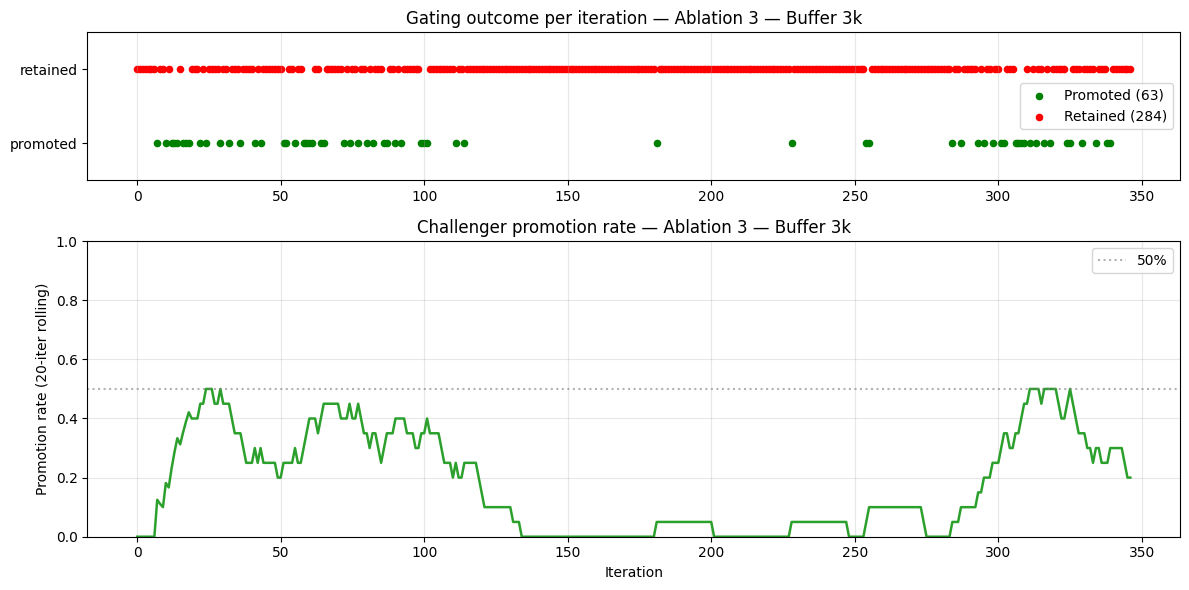

In [ ]:
plot_promotion('results/abl3_buffer_3k/training_log.json', 'Ablation 3 — Buffer 3k')

## Ablation 4 — Gate 50 games

results/abl4_gate_50/training_log.json: iters=264 promoted=40 retained=224 overall_rate=15.2%


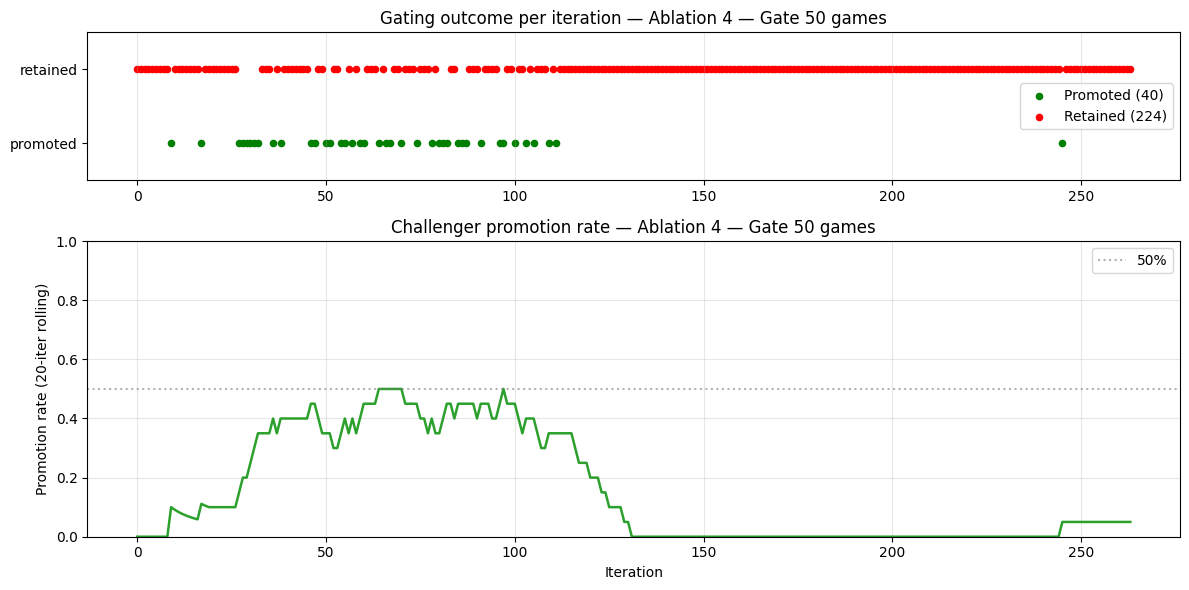

In [ ]:
plot_promotion('results/abl4_gate_50/training_log.json', 'Ablation 4 — Gate 50 games')

## Ablation 5 — Gate 120 games

results/abl5_gate_120/training_log.json: iters=69 promoted=14 retained=55 overall_rate=20.3%


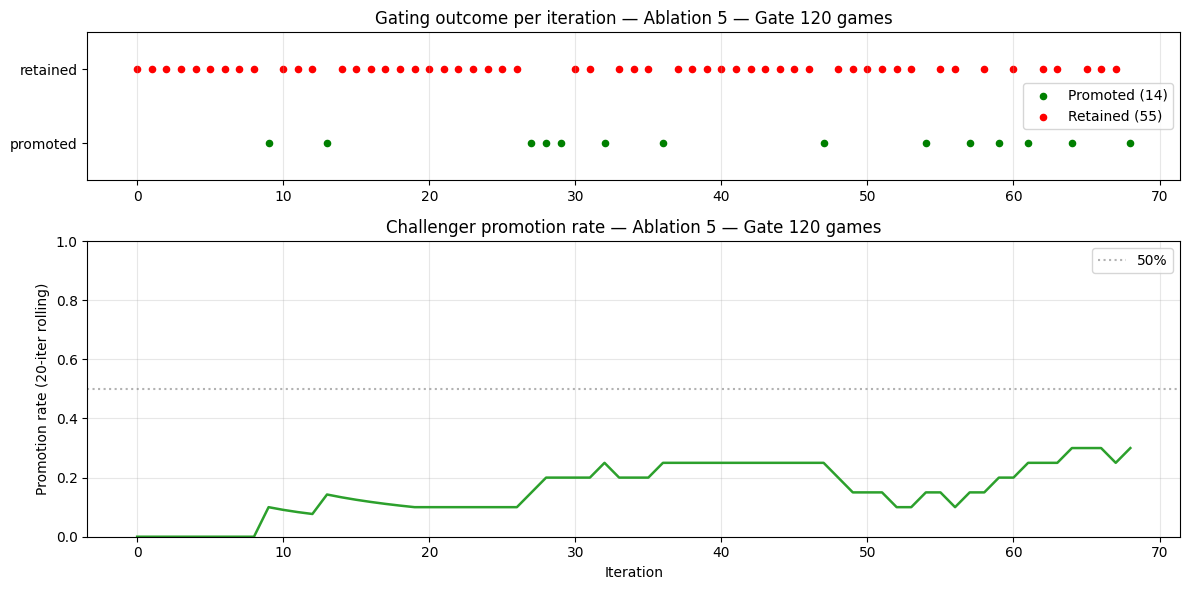

In [ ]:
plot_promotion('results/abl5_gate_120/training_log.json', 'Ablation 5 — Gate 120 games')

## Ablation 6 — Steps 50/iter

results/abl6_steps_50/training_log.json: iters=509 promoted=45 retained=464 overall_rate=8.8%


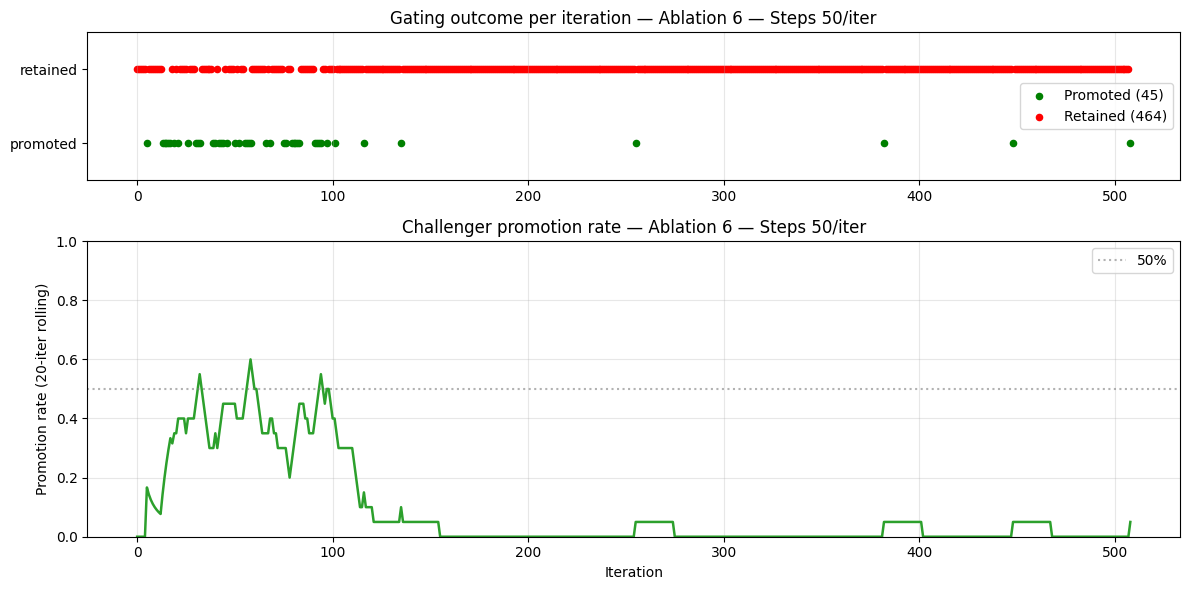

In [ ]:
plot_promotion('results/abl6_steps_50/training_log.json', 'Ablation 6 — Steps 50/iter')

## Ablation 7 — Steps 100/iter

results/abl7_steps_100/training_log.json: iters=316 promoted=98 retained=218 overall_rate=31.0%


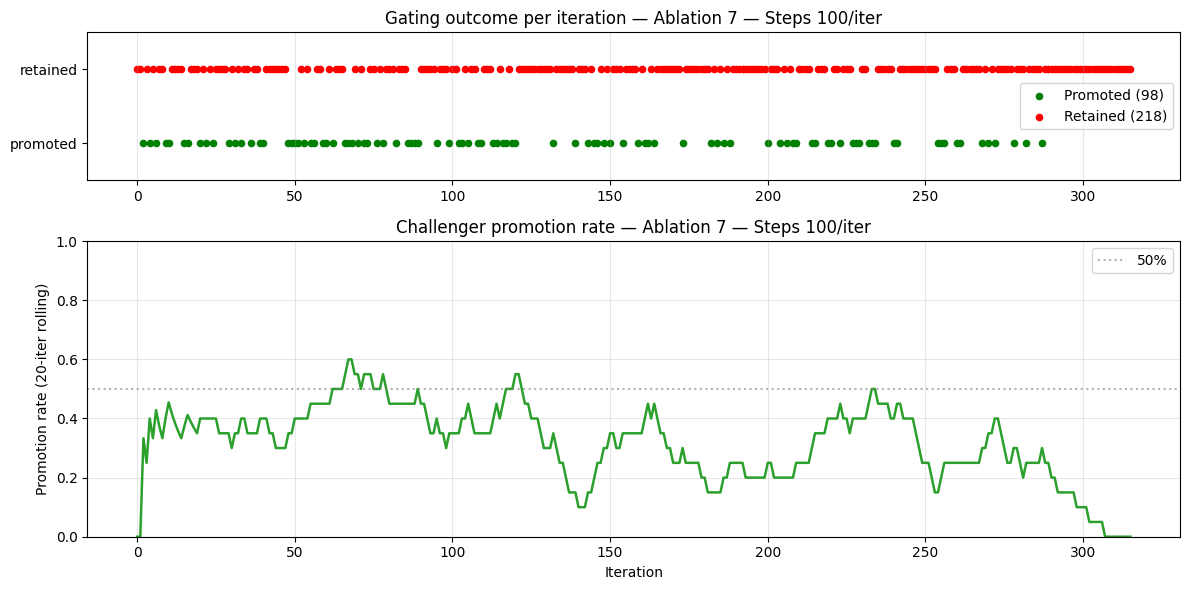

In [ ]:
plot_promotion('results/abl7_steps_100/training_log.json', 'Ablation 7 — Steps 100/iter')

## SGD gate run (long baseline, ~890 iters)

results/sgd_gate_run/training_log.json: iters=895 promoted=244 retained=651 overall_rate=27.3%


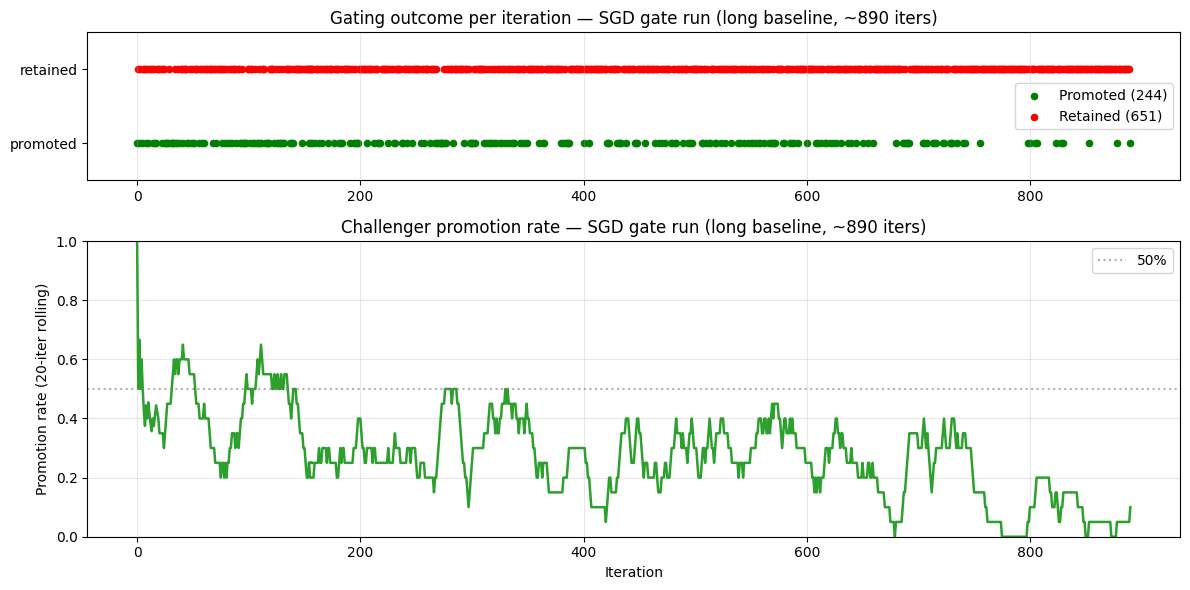

In [ ]:
plot_promotion('results/sgd_gate_run/training_log.json', 'SGD gate run (long baseline, ~890 iters)')